# 1. Preparation

## 1.1 Prepare environment

In [1]:
# List all NVIDIA GPUs as available in this computer (or Colab's session)
!nvidia-smi

Thu Sep  3 16:46:52 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install torchinfo

In [3]:
import sys
print( f"Python {sys.version}\n" )

import random
import time

import numpy as np
print( f"NumPy {np.__version__}\n" )

import matplotlib.pyplot as plt
%matplotlib inline

import torchinfo
print( f"torchinfo {torchinfo.__version__}" )

# https://docs.pytorch.org/vision/0.21/transforms.html
import torchvision
print( f"torchvision {torchvision.__version__}" )
import torchvision.transforms.v2 as T

import torch
print( f"PyTorch {torch.__version__}" )

# Get all available accelerators such as CUDA, MPS, MTIA, or XPU
num_accelerators = torch.accelerator.device_count()

if (num_accelerators <= 0):
    print("|- No hardware accelerators found. Using CPU only.")
else:
    print(f"|- PyTorch detected {num_accelerators} hardware accelerator(s)")
    print(f"|- PyTorch detected '{torch.accelerator.current_accelerator().type.upper()}' as the current accelerator")

    # Check cuda availability
    if torch.cuda.is_available():
        num_gpus = torch.cuda.device_count()
        print(f"|- PyTorch detected {num_gpus} CUDA GPU(s):")

        # Important: The CUDA version in "nvidia-smi" must be equal or higher than "torch.version.cuda".
        # If they mismatch, it may cause silent hangs during heavy CUDA operations.
        # In that case, reinstall PyTorch from pytorch.org with the correct CUDA version.
        print(f"   |- {torch.version.cuda = }")
    for i in range(num_gpus):
        print(f"   |- CUDA GPU {i}: {torch.cuda.get_device_name(i)}")

Python 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]

NumPy 2.1.3

torchinfo 1.8.0
torchvision 0.26.0+cu128
PyTorch 2.11.0+cu128
|- PyTorch detected 1 hardware accelerator(s)
|- PyTorch detected 'CUDA' as the current accelerator
|- PyTorch detected 1 CUDA GPU(s):
   |- torch.version.cuda = '12.8'
   |- CUDA GPU 0: Tesla T4


## 1.2 Prepare global variables/functions

In [4]:
# Reproducibility & Device Configuration
def set_seeds(seed=42):
    """Sets fixed seeds for reproducibility across all libraries."""
    random.seed(seed)     # Controls Python's built-in random numbers.
    np.random.seed(seed)  # Controls NumPy's random arrays.
    torch.manual_seed(seed)           # Controls CPU weight initialization.
    torch.cuda.manual_seed_all(seed)  # Controls GPU weight initialization.

    # Ensure deterministic behavior for some PyTorch operations
    torch.backends.cudnn.deterministic = True # Ensure the GPU doesn't use "fast but slightly random" algorithms for math
    torch.backends.cudnn.benchmark = False
    print(f"Seeds set to {seed} for reproducibility.")

set_seeds(42)

Seeds set to 42 for reproducibility.


In [5]:
# Detect GPU (CUDA), Apple Silicon (MPS), or fallback to CPU
# 'device' is a scalar flag, not a tensor
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# 2. Prepare the MNIST dataset

## 2.1 Create the transform pipeline (including preprocess and data augmentation)

In [6]:
# For training, define the pipeline to be applied on-the-fly as each batch is loaded
train_transform = T.Compose([
    # Convert a tensor, ndarray, or PIL image to torchvision's Image (no value scaling)
    T.ToImage(),

    # Some data augmentation
    T.RandomRotation(degrees=45),   # Randomly rotate +/- 45 degrees
    T.RandomAffine(degrees=0, translate=(0.1, 0.1)), # Small shifts

    # The next step of normalization expects float input
    # So convert to float32 and scale to [0, 1] here
    T.ToDtype(torch.float32, scale=True),

    # MNIST-specific normalization (computed based on the scaled [0,1] version of MNIST)
    T.Normalize(mean=(0.1307,), std=(0.3081,))
])

In [7]:
# Validation/Test transforms should NOT include random augmentations
valtest_transform = T.Compose([
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=(0.1307,), std=(0.3081,))
])

## 2.2 Data spliting and DataLoader

In [8]:
# Load the full training dataset (train+val) twice, with their RESPECTIVE transforms
# This is because we want the train set and the val set to use two different transformations
train_unsplit_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=train_transform)
val_unsplit_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=valtest_transform)
print(f"\nTrain Dataset Size (not splitted yet): {len(train_unsplit_dataset)}")
print(f"Val Dataset Size (not splitted yet): {len(val_unsplit_dataset)}")

# Load the test set with tranformation
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=valtest_transform)
print(f"Test Dataset Size: {len(test_dataset)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 514kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.48MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.8MB/s]



Train Dataset Size (not splitted yet): 60000
Val Dataset Size (not splitted yet): 60000
Test Dataset Size: 10000


In [9]:
# Split the full training dataset into two sub-datasets: train (50k) and val (10k)
total_len = len(train_unsplit_dataset)
train_len = 50000
val_len = total_len - train_len

# Generate a SINGLE set of split indices using random_split
generator = torch.Generator().manual_seed(42)   # Set seed for reproducible splits
train_dummy, val_dummy = torch.utils.data.random_split(range(total_len), [train_len, val_len], generator=generator)

# Extract indices from the dummy split
train_indices = train_dummy.indices
val_indices = val_dummy.indices

# Wrap each dataset using the EXACT SAME indices
train_dataset = torch.utils.data.Subset(train_unsplit_dataset, train_indices)
val_dataset = torch.utils.data.Subset(val_unsplit_dataset, val_indices)
print(f"Train Dataset Size: {len(train_dataset)}")
print(f"Val Dataset Size: {len(val_dataset)}")

# --- Verification ---
overlap = set(train_dataset.indices).intersection(set(val_dataset.indices))
if ( len(overlap) == 0):
    print(f"No sample overlapping between the train and val sets.")
else:
    print(f"Warning!!! There are {len(overlap)} samples appear in both train and val sets.")

Train Dataset Size: 50000
Val Dataset Size: 10000
No sample overlapping between the train and val sets.


In [10]:
print(f"Train Dataset Size: {len(train_dataset)}")
sample_img, sample_label = train_dataset[0]
print(f"|- Object type: {type(sample_img)}")   # PIL Image
print(f"|- Image Shape: {sample_img.shape}")   # (28, 28)
print(f"|- Pixel Range (Min/Max): {np.asarray(sample_img).min()}, {np.asarray(sample_img).max()}")

print(f"\nVal Dataset Size: {len(val_dataset)}")
sample_img, sample_label = val_dataset[0]
print(f"|- Object type: {type(sample_img)}")   # PIL Image
print(f"|- Image Shape: {sample_img.shape}")   # (28, 28)
print(f"|- Pixel Range (Min/Max): {np.asarray(sample_img).min()}, {np.asarray(sample_img).max()}")

print(f"\nTest Dataset Size: {len(test_dataset)}")
sample_img, sample_label = test_dataset[0]
print(f"|- Object type: {type(sample_img)}")   # PIL Image
print(f"|- Image Shape: {sample_img.shape}")   # (28, 28)
print(f"|- Pixel Range (Min/Max): {np.asarray(sample_img).min()}, {np.asarray(sample_img).max()}")

Train Dataset Size: 50000
|- Object type: <class 'torchvision.tv_tensors._image.Image'>
|- Image Shape: torch.Size([1, 28, 28])
|- Pixel Range (Min/Max): -0.4242129623889923, 2.821486711502075

Val Dataset Size: 10000
|- Object type: <class 'torchvision.tv_tensors._image.Image'>
|- Image Shape: torch.Size([1, 28, 28])
|- Pixel Range (Min/Max): -0.4242129623889923, 2.821486711502075

Test Dataset Size: 10000
|- Object type: <class 'torchvision.tv_tensors._image.Image'>
|- Image Shape: torch.Size([1, 28, 28])
|- Pixel Range (Min/Max): -0.4242129623889923, 2.821486711502075


In [11]:
# DataLoaders handle batching and shuffling
# train_loader: Use num_workers > 0 enables multi-process data loading for speed
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

## 2.3 Visualize the augmented images (Optional)

In [12]:
def visualize_stochastic_augmentation(dataset, index=0):
    """Shows the same image (dataset[index]) transformed 5 different times."""
    plt.figure(figsize=(15, 3))

    for i in range(5):
        # Every time we call __getitem__, a NEW random transform is applied
        image, label = dataset[index]

        # Convert to numpy and remove channel dim for grayscale plotting
        img_np = image.squeeze().numpy()

        plt.subplot(1, 5, i + 1)
        plt.imshow(img_np, cmap='gray')
        plt.title(f"Attempt {i+1}")
        plt.axis('off')

    plt.suptitle(f"Random Augmentations of Digit: {label}")
    plt.show()

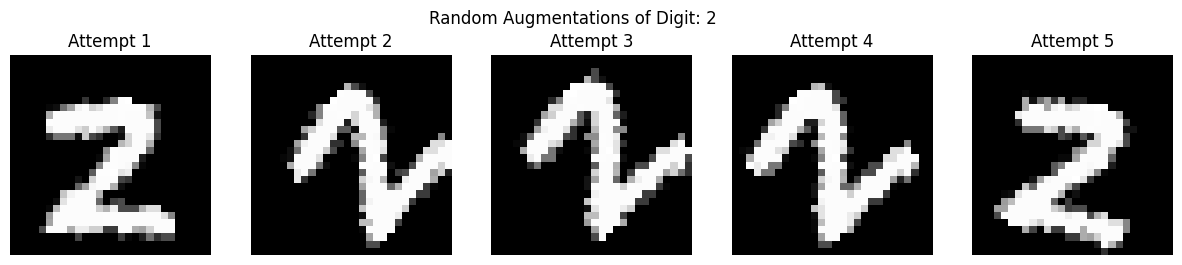

In [13]:
# Visualize an image from the train set (random augmentation included)
visualize_stochastic_augmentation(train_dataset, index=42)

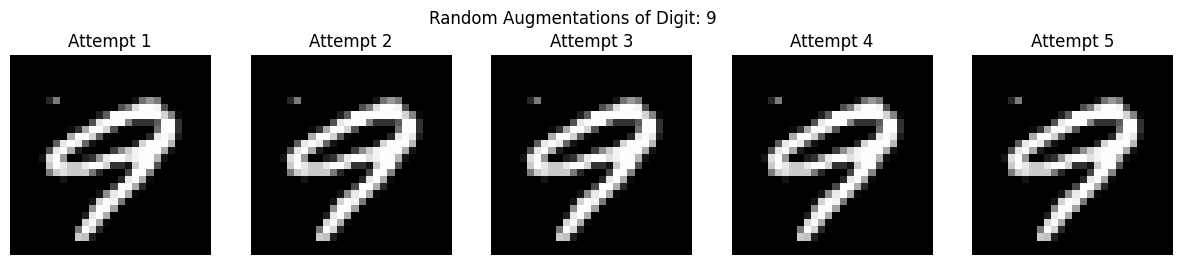

In [14]:
# For comparison, visualize an image from the val set (NO random augmentation)
visualize_stochastic_augmentation(val_dataset, index=42)

# 3. Create a CNN network

In [15]:
class ImageCNN(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.features = torch.nn.Sequential(
            torch.nn.Conv2d(1, 16, kernel_size=3, padding=1),  # (16, 28, 28)
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2),                             # (16, 14, 14)
            torch.nn.Conv2d(16, 32, kernel_size=3, padding=1), # (32, 14, 14)
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2)                              # (32, 7, 7)
        )
        self.classifier = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(32 * 7 * 7, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

In [16]:
model = ImageCNN().to(device)
model

ImageCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [17]:
torchinfo.summary(model)

Layer (type:depth-idx)                   Param #
ImageCNN                                 --
├─Sequential: 1-1                        --
│    └─Conv2d: 2-1                       160
│    └─ReLU: 2-2                         --
│    └─MaxPool2d: 2-3                    --
│    └─Conv2d: 2-4                       4,640
│    └─ReLU: 2-5                         --
│    └─MaxPool2d: 2-6                    --
├─Sequential: 1-2                        --
│    └─Flatten: 2-7                      --
│    └─Linear: 2-8                       100,416
│    └─ReLU: 2-9                         --
│    └─Linear: 2-10                      650
Total params: 105,866
Trainable params: 105,866
Non-trainable params: 0

# 4. Train and visualize

## 4.1 Training and validating

In [18]:
# =================================================================
# TRAINING LOOP (Sample-Based Accumulation)
# =================================================================
def train_and_validate(model, device, epochs=5):

    model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = torch.nn.CrossEntropyLoss()

    history = {'t_loss': [], 't_acc': [], 'v_loss': [], 'v_acc': []}

    for epoch in range(epochs):
        epoch_start = time.time()

        # --- TRAINING PHASE ---
        model.train()
        running_loss = 0.0
        correct_samples = 0
        samples_processed = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            current_batch_size = images.size(0) # Handle potential smaller final batch

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # Accumulate loss multiplied by batch size to get total sample loss
            running_loss += loss.detach() * current_batch_size
            samples_processed += current_batch_size

            # Accumulate the number of correct predictions
            with torch.inference_mode():
                preds = outputs.detach().argmax(dim=1)
                correct_samples += (preds == labels).sum().item()

        avg_train_loss = running_loss.item() / samples_processed
        avg_train_acc = (correct_samples / samples_processed) * 100

        # --- VALIDATION PHASE ---
        model.eval()
        v_running_loss = 0.0
        v_correct_samples = 0
        v_samples_processed = 0

        with torch.inference_mode():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                b_size = images.shape[0]

                outputs = model(images)
                loss = criterion(outputs, labels)

                v_running_loss += loss.item() * b_size
                preds = outputs.argmax(dim=1)
                v_correct_samples += (preds == labels).sum().item()
                v_samples_processed += b_size

        avg_v_loss = v_running_loss / v_samples_processed
        avg_v_acc = (v_correct_samples / v_samples_processed) * 100

        history['t_loss'].append(avg_train_loss)
        history['t_acc'].append(avg_train_acc)
        history['v_loss'].append(avg_v_loss)
        history['v_acc'].append(avg_v_acc)

        epoch_duration = time.time() - epoch_start
        print(f"Epoch {epoch+1} | Time: {epoch_duration:.4f}s | Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.2f}% | Val Loss: {avg_v_loss:.4f} | Val Acc: {avg_v_acc:.2f}%")

    return history

In [19]:
print("Training CNN...")

# --- Hardware-dependent training time ---
# CPU: ~80 seconds per epoch
# NVIDIA T4 GPU (15GB VRAM): ~58 seconds per epoch
# NVIDIA G4 GPU (NVIDIA RTX PRO 6000 Blackwell: 95.6GB VRAM): ~7 seconds per epoch
history = train_and_validate(model, device, epochs=20)

Training CNN...
Epoch 1 | Time: 57.9795s | Train Loss: 0.6088 | Train Acc: 80.26% | Val Loss: 0.1542 | Val Acc: 95.28%
Epoch 2 | Time: 58.4215s | Train Loss: 0.2401 | Train Acc: 92.54% | Val Loss: 0.1004 | Val Acc: 96.99%
Epoch 3 | Time: 58.1705s | Train Loss: 0.1813 | Train Acc: 94.36% | Val Loss: 0.0895 | Val Acc: 97.35%
Epoch 4 | Time: 57.8090s | Train Loss: 0.1511 | Train Acc: 95.33% | Val Loss: 0.0890 | Val Acc: 97.35%
Epoch 5 | Time: 57.0482s | Train Loss: 0.1317 | Train Acc: 95.86% | Val Loss: 0.0702 | Val Acc: 97.98%
Epoch 6 | Time: 63.0885s | Train Loss: 0.1189 | Train Acc: 96.27% | Val Loss: 0.0705 | Val Acc: 97.92%
Epoch 7 | Time: 63.2764s | Train Loss: 0.1116 | Train Acc: 96.58% | Val Loss: 0.0589 | Val Acc: 98.18%
Epoch 8 | Time: 58.1518s | Train Loss: 0.1035 | Train Acc: 96.82% | Val Loss: 0.0673 | Val Acc: 97.99%
Epoch 9 | Time: 57.5075s | Train Loss: 0.0958 | Train Acc: 97.04% | Val Loss: 0.0601 | Val Acc: 98.17%
Epoch 10 | Time: 57.0098s | Train Loss: 0.0911 | Train Ac

## 4.2 Learning curve visualization

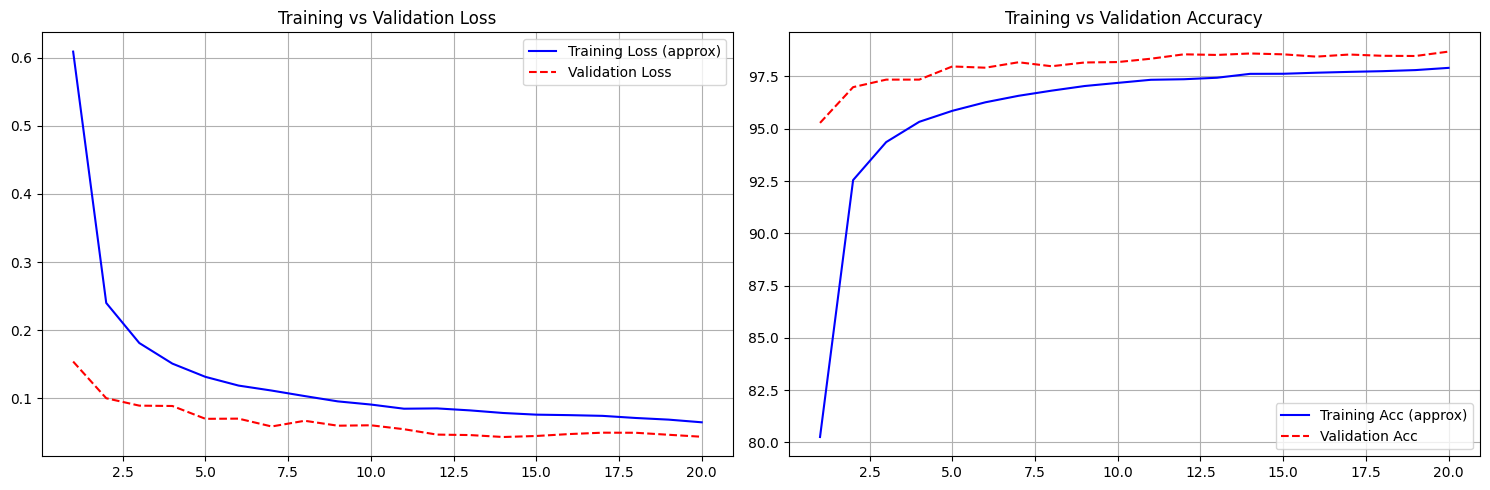

In [25]:
epochs = range(1, len(history['t_loss']) + 1)
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# --- Loss ---
ax[0].plot(epochs, history['t_loss'], 'b-', label='Training Loss (approx)')
ax[0].plot(epochs, history['v_loss'], 'r--', label='Validation Loss')
ax[0].set_title('Training vs Validation Loss')
ax[0].legend()
ax[0].grid(True)

# --- Accuracy ---
ax[1].plot(epochs, history['t_acc'], 'b-', label='Training Acc (approx)')
ax[1].plot(epochs, history['v_acc'], 'r--', label='Validation Acc')
ax[1].set_title('Training vs Validation Accuracy')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

# 5. Evaluate the models on test set

In [21]:
@torch.inference_mode()
def evaluate_model(model, device, test_loader):
    model.to(device)
    model.eval()

    running_loss = 0.0
    correct_samples = 0
    samples_processed = 0
    criterion = torch.nn.CrossEntropyLoss()

    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        b_size = images.shape[0]

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * b_size
        preds = outputs.argmax(dim=1)
        correct_samples += (preds == labels).sum().item()
        samples_processed += b_size

    avg_loss = running_loss / samples_processed
    avg_acc = (correct_samples / samples_processed) * 100

    print(f"Test Loss: {avg_loss:.4f} | Test Accuracy: {avg_acc:.2f}%")

In [22]:
print("Evaluating CNN...")
evaluate_model(model, device, test_loader)

Evaluating CNN...
Test Loss: 0.0360 | Test Accuracy: 98.81%


# 6. Inference

In [32]:
def visualize_test_results(model, device, title, start_from=0):
    """
    Visualizes a 4x5 grid of test results starting from a specific index.
    Displays global index, predicted label, and actual label.
    """
    model.eval()

    # 1. Select the specific range of 20 images using a Subset
    # We create a temporary loader for just these 20 samples
    num_images = 20 # 4 rows * 5 columns
    indices = list(range(start_from, start_from + num_images))
    subset = torch.utils.data.Subset(test_dataset, indices)
    temp_loader = torch.utils.data.DataLoader(subset, batch_size=num_images, shuffle=False)

    # 2. Get the data
    images, labels = next(iter(temp_loader))
    images, labels = images.to(device), labels.to(device)

    with torch.inference_mode():
        outputs = model(images)
        preds = outputs.argmax(dim=1)

        # (Optional) Compute probabilities (0.0 ~ 1.0) to show users
        probs = torch.nn.functional.softmax(outputs, dim=1)

    # 3. Setup the 4x5 Grid
    fig, axes = plt.subplots(4, 5, figsize=(15, 12))
    fig.suptitle(f"{title} (Starting from index {start_from})", fontsize=18, y=0.95)

    for i, ax in enumerate(axes.flat):
        # Calculate the global index for this specific image
        global_idx = start_from + i

        # Prepare image for plotting (C, H, W) -> (H, W)
        img = images[i].cpu().squeeze()
        ax.imshow(img, cmap='gray')

        # Comparison logic for border color
        correct = (preds[i] == labels[i])
        color = 'green' if correct else 'red'

        # Apply thick colored borders to highlight errors
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(3)

        # Set title with Index, Prediction (P), and Actual (A)
        pred_idx = preds[i].item()
        ax.set_title(f"Idx: {global_idx}\nPredict: {pred_idx} | Actual: {labels[i]}\nConfidence: {probs[i,pred_idx].item() * 100:.2f}%",
                     color=color, fontsize=10)

        # Clean up axes for better visibility
        ax.set_xticks([]); ax.set_yticks([])

    plt.tight_layout(rect=[0, 0.03, 1, 0.93]) # Adjust layout to fit main title
    plt.show()

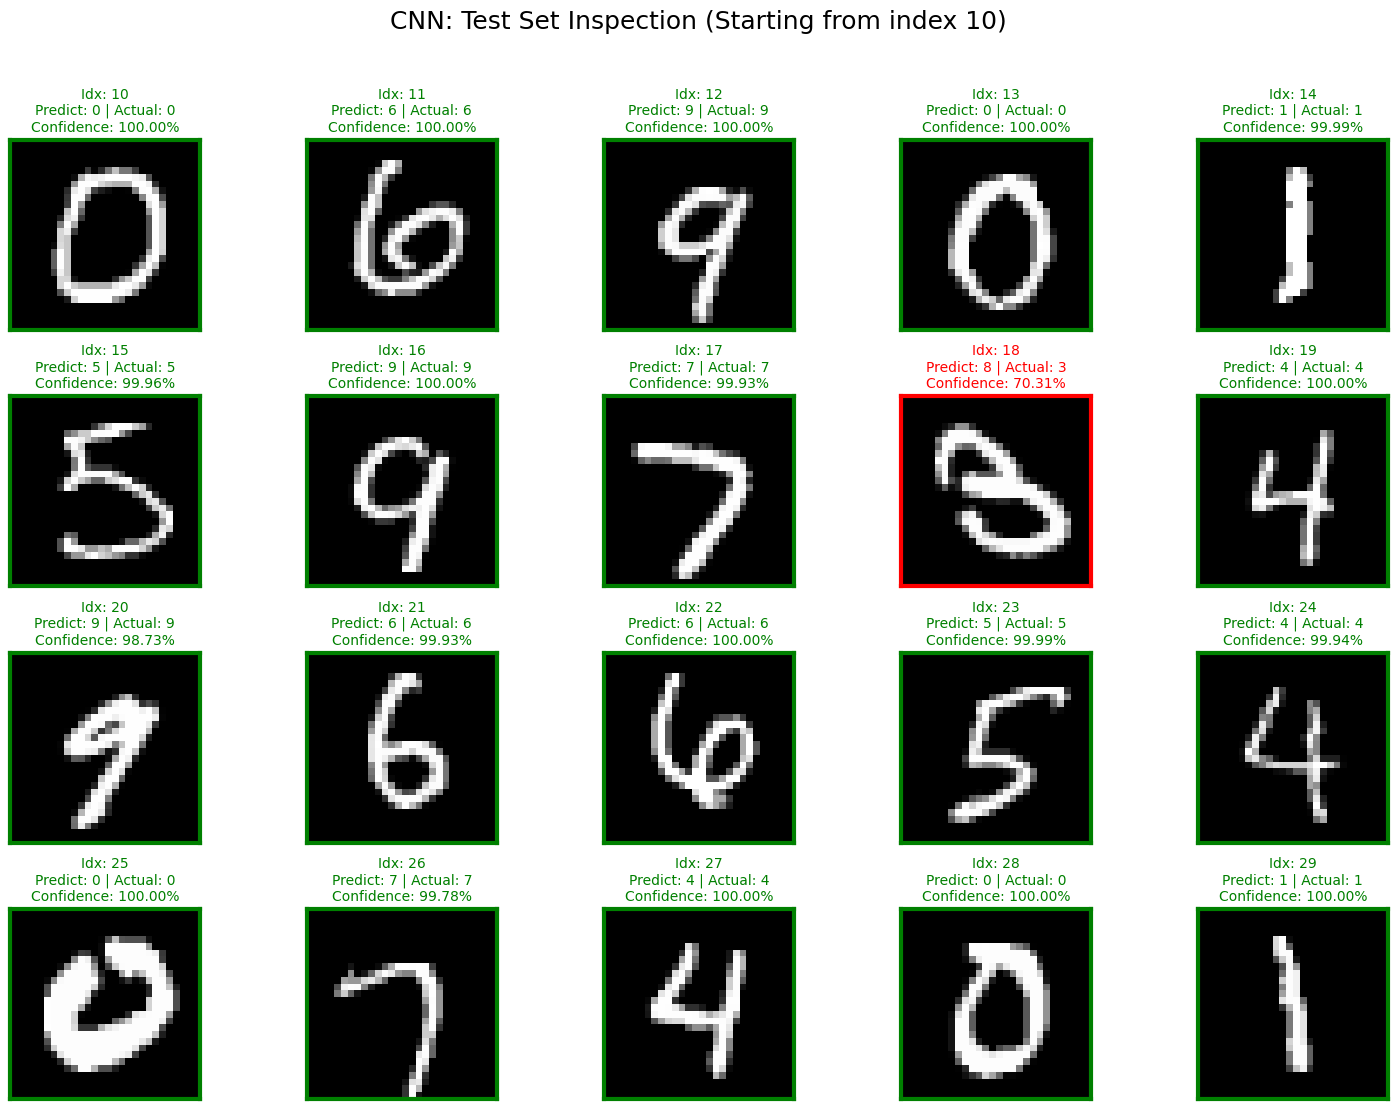

In [35]:
visualize_test_results(model, device, "CNN: Test Set Inspection", start_from=10)